In [8]:
import pandas as pd
from scipy.stats import kstest
from matplotlib import pyplot as plt
from scipy import stats
random_seed = 42

### Kolmogorov-Smirnov Goodness of Fit Test

Kolmogorov-Smirnov test answers the question:

> "How likely is it that we would see a collection of samples like this if they were drawn from that probability distribution?"

Or given two samples:

> "How likely is it that we would see two sets of samples like this if they were drawn from the same (but unknown) probability distribution?"

Uniform distribution has 2 parameters - $a$ and $b$, but in the scipy we use $a$ as a `loc` and $b - a$ as a `scale` parameters.

In [45]:
a = loc = 5
b = 10
scale = b - a
print(f'a (loc): {a}', f'b: {b}', f'scale (b - a): {scale}', sep='\n')

a (loc): 5
b: 10
scale (b - a): 5


We will generate some sample data for testing from uniform distribution to check if test is working properly.


`rvs` function - random variable sample - generate data with given parameters from given distribution

In [33]:
data = stats.uniform.rvs(loc=a, scale=scale, size=1000, random_state=random_seed)

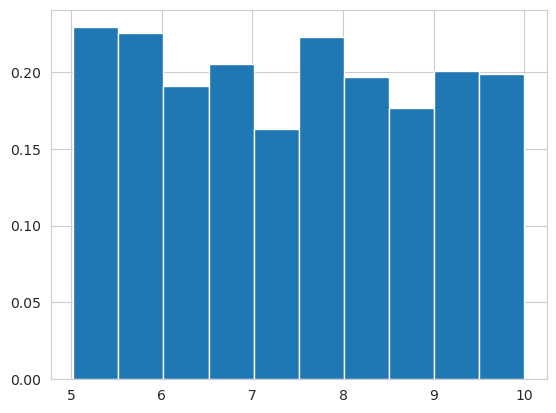

In [34]:
plt.hist(data, bins=10, density=True)
plt.show()

Let's see cumulative distribution function:

In [35]:
data_ecdf = stats.ecdf(data)

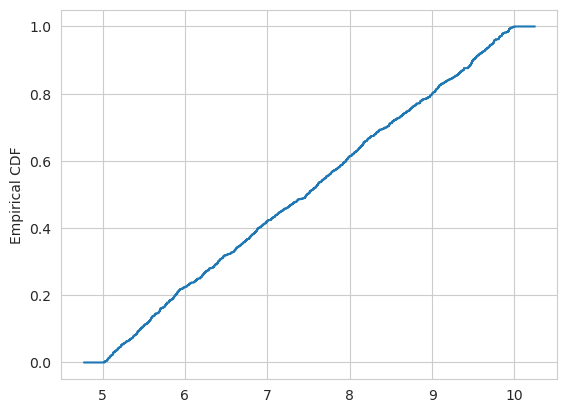

In [36]:
ax = plt.subplot()
data_ecdf.cdf.plot(ax)
ax.set_ylabel('Empirical CDF')
plt.show()

Let's apply the test:

In [37]:
kstest(data, 'uniform')

KstestResult(statistic=1.0, pvalue=0.0, statistic_location=5.023160115023014, statistic_sign=-1)

Something is clearly wrong - the reason is that for comparison it uses uniform distribution with default parameters `loc` = 0 and `scale` = 1

There are two ways to fix this:
1) rescale our data
2) add loc and scale parameters to `args` parameter
3) sample our uniform distribution

#### 1. Rescaling the data

In [46]:
rescaled_data = (data - loc) / scale

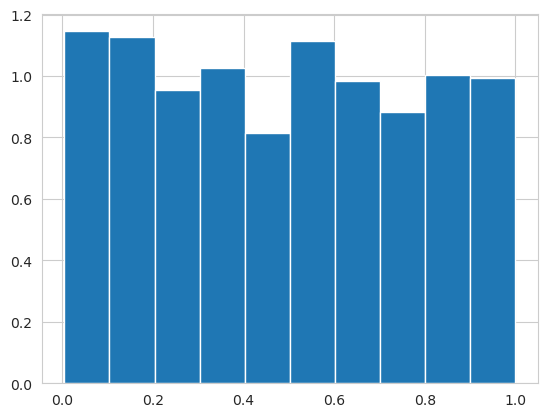

In [40]:
plt.hist(rescaled_data, bins=10, density=True)
plt.show()

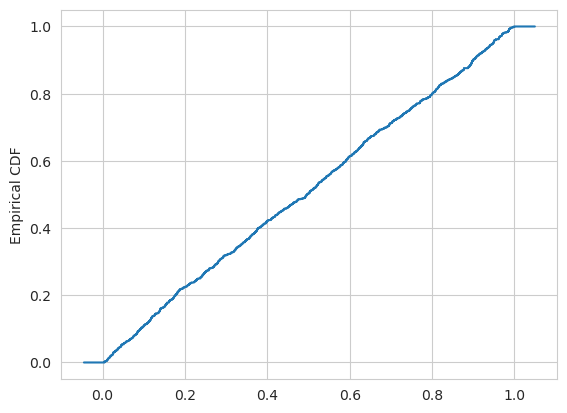

In [42]:
data_ecdf = stats.ecdf(rescaled_data)
ax = plt.subplot()
data_ecdf.cdf.plot(ax)
ax.set_ylabel('Empirical CDF')
plt.show()

In [43]:
kstest(rescaled_data, 'uniform')

KstestResult(statistic=0.029956251442476572, pvalue=0.3243752124357776, statistic_location=0.18704374855752343, statistic_sign=1)

`p-value` > 0.05, thus we cannot reject null hypothesis that the data comes from uniform distribution.

2. Adding `loc` and `scale` parameters

In [47]:
kstest(data, 'uniform', args=(a, scale))

KstestResult(statistic=0.029956251442476572, pvalue=0.3243752124357776, statistic_location=5.935218742787617, statistic_sign=1)

`p-value` and `statistic` are the same, though `statistic_location` is different. The reason of the difference may be because of higher loc and scale used in the latter test.

#### 3. Sampling our own uniform data (basically comparing two distributions)

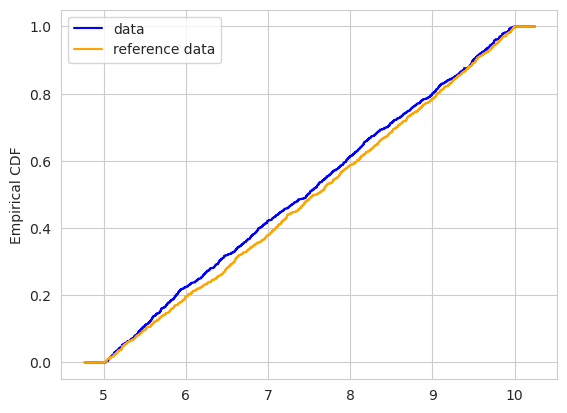

In [55]:
ref_data = stats.uniform.rvs(loc=loc, scale=scale, size=len(data), random_state=random_seed + 1)

ref_data_ecdf = stats.ecdf(ref_data)
data_ecdf = stats.ecdf(data)

ax = plt.subplot()
data_ecdf.cdf.plot(ax, color='blue', label='data')
ref_data_ecdf.cdf.plot(ax, color='orange', label='reference data')
ax.set_ylabel('Empirical CDF')
ax.legend()
plt.show()

In [56]:
kstest(data, ref_data)

KstestResult(statistic=0.047, pvalue=0.21939649929677082, statistic_location=6.432706260641422, statistic_sign=1)

As expected, we cannot reject the null hypothesis, that both distributions were samples from uniform distribution.

### References

- [SciPy Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html)
- [Wikipedia](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test)
- [How to compare Two Distributions in Practice - Medium](https://medium.com/@noorfatimaafzalbutt/discretization-binning-in-machine-learning-da3ad71ceb36)